In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [3]:
df.head()

df.info()

df.describe()

df['Attrition'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,count
Attrition,
No,1233
Yes,237


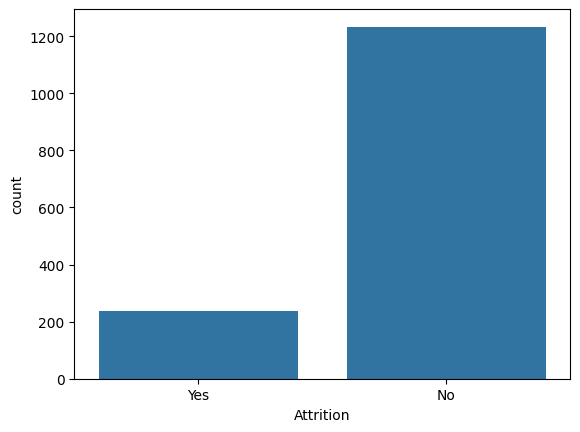

In [4]:
sns.countplot(x='Attrition', data=df)
plt.show()

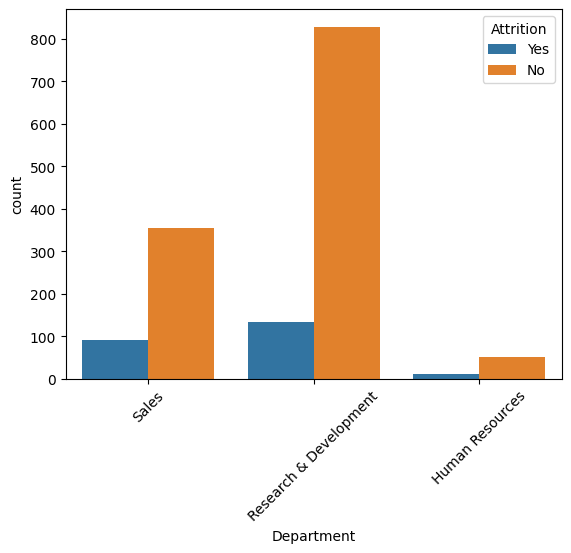

In [5]:
sns.countplot(x='Department',
              hue='Attrition',
              data=df)
plt.xticks(rotation=45)
plt.show()

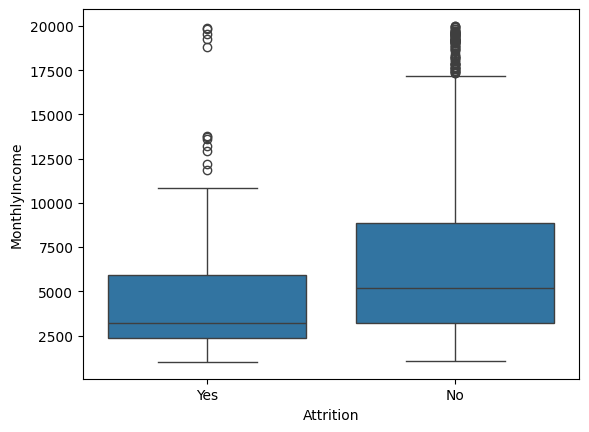

In [6]:
sns.boxplot(x='Attrition',
            y='MonthlyIncome',
            data=df)
plt.show()

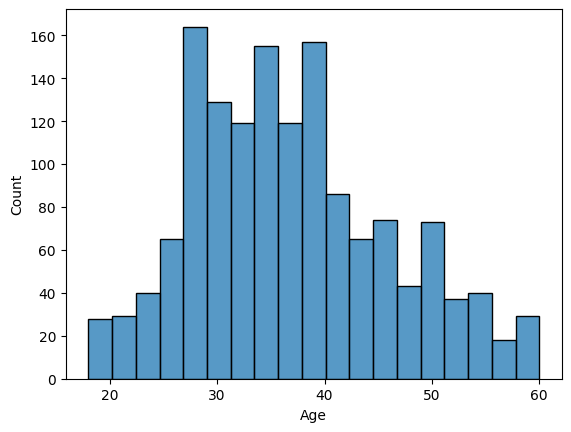

In [7]:
sns.histplot(df['Age'])
plt.show()

In [8]:
df['Attrition'] = df['Attrition'].map({
'Yes':1,
'No':0
})

In [9]:
df = pd.get_dummies(df,
drop_first=True)

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition',axis=1)

y = df['Attrition']

X_train,X_test,y_train,y_test = train_test_split(
X,y,
test_size=0.2,
random_state=42)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [12]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

accuracy_score(y_test,pred)

0.8673469387755102

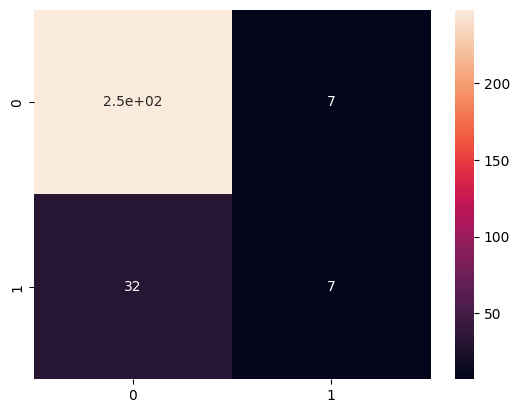

In [13]:
from sklearn.metrics import confusion_matrix

sns.heatmap(
confusion_matrix(y_test,pred),
annot=True)
plt.show()